# Fase 1: EDA

In [300]:
# Importamos librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer 
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer 
from sklearn.impute import KNNImputer 
pd.set_option("display.max_columns", None)

In [301]:
df_hr = pd.read_csv("hr.csv")

In [302]:
def exploracion_inicial(df,name="dataframe"):
    print(f"El dataframe '{name}' tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
    display(df.head(2))
    print("="*150)
    display(df.tail(2))
    print("="*150)
    display(df.sample(2))
    print("="*150)
    print(f"Listamos abajo el conteo de no-nulos junto con el tipo de dato:")
    print("="*150)
    print(df.info())
    print("="*150)

In [303]:
exploracion_inicial(df_hr, "df_hr")

El dataframe 'df_hr' tiene 1474 filas y 35 columnas.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sALES eXECUTIVE,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,rESEARCH sCIENTIST,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1472,24.0,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,hUMAN rESOURCES,3.0,Married,1555.0,11585,1,Y,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0
1473,45.0,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,rESEARCH sCIENTIST,1.0,Divorced,9724.0,18787,2,Y,No,17,3,3,NaN,1,25,2.0,3,1,0,0,0.0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
627,52.0,No,Travel_Frequently,890,Research & Development,25,4,Medical,1,867,3,Female,81,2,4,mANUFACTURING dIRECTOR,4.0,Married,13826.0,19028,3,Y,No,22,4,3,80.0,0,31,NaN,3,9,8,0,0.0
1005,29.0,No,Travel_Rarely,332,Human Resources,17,3,Other,1,1419,2,Male,51,2,3,hUMAN rESOURCES,1.0,Single,7988.0,9769,1,Y,No,13,3,1,80.0,0,10,3.0,2,10,9,0,9.0


Listamos abajo el conteo de no-nulos junto con el tipo de dato:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1401 non-null   float64
 1   Attrition                 1474 non-null   object 
 2   BusinessTravel            1357 non-null   object 
 3   DailyRate                 1474 non-null   int64  
 4   Department                1445 non-null   object 
 5   DistanceFromHome          1474 non-null   int64  
 6   Education                 1474 non-null   int64  
 7   EducationField            1416 non-null   object 
 8   EmployeeCount             1474 non-null   int64  
 9   EmployeeNumber            1474 non-null   int64  
 10  EnvironmentSatisfaction   1474 non-null   int64  
 11  Gender                    1474 non-null   object 
 12  HourlyRate                1474 non-null   int64  
 13 

Homogeneizar nombre de las columnas (letras en minuscula e intentar separar palabras con guion bajo )

* Age: tenemos que cambiar de float a int. Y tenemos nulos. 
* Attrition: Cambiar de str a boleano. Y no hay nulos.
* Business travel: Hay nulos. Tipo de dato correcto.
* Departamento: Hay nulos. Tipo dato correcto.
* Education field: Hay nulos. Tipo de dato correcto. 
* Employeecount: La podremos borrar seguramente (no nos da info)
* Employee number: Podemos cambiar de int a str (sirve como ID, no hacemos estadistica con el)
* Job satistfaction: cambiar de float a int. Y hay nulos.
* Marital status: Hay nulos.
* Overtime: Podemos pasar de str a boleano. Y hay nulos.
* Standard hours: Hay nulos. La podremos borrar seguramente porque el valor es 80 solo. 
* Training times last year: Pasar de float a int?? Hay nulos.
* Year with current manager: Pasar de float a int. Hay nulos.




Identificación de valores nulos

In [304]:
df_hr.isnull().sum() 

Age                          73
Attrition                     0
BusinessTravel              117
DailyRate                     0
Department                   29
DistanceFromHome              0
Education                     0
EducationField               58
EmployeeCount                 0
EmployeeNumber                0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction              29
MaritalStatus               132
MonthlyIncome                14
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                     44
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours               164
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear        88
WorkLifeBalance               0
YearsAtC

In [305]:
porcentaje_nulos= (df_hr.isnull().sum() / df_hr.shape[0] * 100).sort_values(ascending=False)
porcentaje_nulos

StandardHours               11.126187
YearsWithCurrManager        10.040706
MaritalStatus                8.955224
BusinessTravel               7.937585
TrainingTimesLastYear        5.970149
Age                          4.952510
EducationField               3.934871
OverTime                     2.985075
JobSatisfaction              1.967436
Department                   1.967436
MonthlyIncome                0.949796
Attrition                    0.000000
EmployeeNumber               0.000000
EmployeeCount                0.000000
Gender                       0.000000
EnvironmentSatisfaction      0.000000
Education                    0.000000
DistanceFromHome             0.000000
DailyRate                    0.000000
JobRole                      0.000000
HourlyRate                   0.000000
JobInvolvement               0.000000
JobLevel                     0.000000
Over18                       0.000000
PercentSalaryHike            0.000000
NumCompaniesWorked           0.000000
MonthlyRate 

In [306]:
def descriptive_analysis(df):
    print("NUMÉRICAS")
    display(df.describe(include="number").T)
    print("CATEGÓRICAS")
    display(df.describe(include="object").T)

In [307]:
descriptive_analysis(df_hr)

NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
Age,1401.0,36.944325,9.105009,18.0,30.00,36.0,43.00,60.0
DailyRate,1474.0,802.702171,403.539530,102.0,465.00,803.0,1157.00,1499.0
DistanceFromHome,1474.0,9.199457,8.104266,1.0,2.00,7.0,14.00,29.0
Education,1474.0,2.911126,1.024267,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1474.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1474.0,1024.471506,602.421193,1.0,488.75,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1474.0,2.723881,1.093280,1.0,2.00,3.0,4.00,4.0
HourlyRate,1474.0,65.887381,20.310444,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1474.0,2.729986,0.712861,1.0,2.00,3.0,3.00,4.0
JobLevel,1474.0,2.063772,1.106055,1.0,1.00,2.0,3.00,5.0


CATEGÓRICAS


,count,unique,top,freq
Attrition,1474,2,No,1236
BusinessTravel,1357,3,Travel_Rarely,955
Department,1445,3,Research & Development,941
EducationField,1416,6,Life Sciences,582
Gender,1474,2,Male,885
JobRole,1474,9,sALES eXECUTIVE,327
MaritalStatus,1342,4,Married,604
Over18,1474,1,Y,1474
OverTime,1430,2,No,1025


In [308]:
def analizar_categorias(df):
    col_cat = df.select_dtypes(include = "object").columns

    for col in col_cat:
        print("=" * 100)
        print(f"Analizamos las categorias de la columna: {col}")
        print("=" * 100)
        print(df[col].unique())

In [309]:
analizar_categorias(df_hr)

Analizamos las categorias de la columna: Attrition
['Yes' 'No']
Analizamos las categorias de la columna: BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel' nan]
Analizamos las categorias de la columna: Department
['Sales' 'Research & Development' nan 'Human Resources']
Analizamos las categorias de la columna: EducationField
['Life Sciences' 'Other' 'Medical' nan 'Marketing' 'Technical Degree'
 'Human Resources']
Analizamos las categorias de la columna: Gender
['Female' 'Male']
Analizamos las categorias de la columna: JobRole
[' sALES eXECUTIVE ' ' rESEARCH sCIENTIST ' ' lABORATORY tECHNICIAN '
 ' mANUFACTURING dIRECTOR ' ' hEALTHCARE rEPRESENTATIVE ' ' mANAGER '
 ' sALES rEPRESENTATIVE ' ' rESEARCH dIRECTOR ' ' hUMAN rESOURCES ']
Analizamos las categorias de la columna: MaritalStatus
['Single' 'Married' 'Divorced' nan 'Marreid']
Analizamos las categorias de la columna: Over18
['Y']
Analizamos las categorias de la columna: OverTime
['Yes' 'No' nan]


* Business travel: Cambiar Non-Travel por Non_Travel
* Job role: hacer capitalize
* Marital: corregir "marreid"

# Fase 2: Transformación de datos

In [310]:
df_hr.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

## Estandarizamos nombre de las columnas

In [311]:
# Homegeneizar nombre de columnas (teniendo en cuenta que vamos a borrar la columna "Over18")

def estandarizar_nombre(nombre):
    resultado = ""
    for i, letra in enumerate(nombre):
        # Si la letra es mayúscula y no es la primera, ponemos un "_"
        if letra.isupper() and i > 0:
            resultado += "_" + letra.lower()
        else:
            resultado += letra.lower()
    return resultado

# Aplicamos el cambio a las columnas:
df_hr.columns = [estandarizar_nombre(col) for col in df_hr.columns]

print(df_hr.columns)


Index(['age', 'attrition', 'business_travel', 'daily_rate', 'department',
       'distance_from_home', 'education', 'education_field', 'employee_count',
       'employee_number', 'environment_satisfaction', 'gender', 'hourly_rate',
       'job_involvement', 'job_level', 'job_role', 'job_satisfaction',
       'marital_status', 'monthly_income', 'monthly_rate',
       'num_companies_worked', 'over18', 'over_time', 'percent_salary_hike',
       'performance_rating', 'relationship_satisfaction', 'standard_hours',
       'stock_option_level', 'total_working_years', 'training_times_last_year',
       'work_life_balance', 'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager'],
      dtype='object')


## Corregimos valores de columnas categóricas

* Business travel: Cambiar Non-Travel por Non_Travel
* Job role: hacer capitalize
* Marital: corregir "marreid"

In [312]:
def limpiar_categoricas(df):
    
    cols = df.select_dtypes(include="object").columns
    
    for col in cols:
        df[col] = df[col].str.strip().str.title().str.replace("-","_")
        if col == "marital_status":
            df[col] = df[col].str.replace('Marreid','Married')

    return df

In [313]:
limpiar_categoricas(df_hr)

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0
2,37.0,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3.0,Single,2090.0,2396,6,Y,Yes,15,3,2,NaN,0,7,3.0,3,0,0,0,0.0
3,33.0,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3.0,Married,2909.0,23159,1,Y,Yes,11,3,3,80.0,0,8,3.0,3,8,7,3,0.0
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2.0,Married,3468.0,16632,9,Y,No,12,3,4,80.0,1,6,3.0,3,2,2,2,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469,34.0,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3.0,Married,4404.0,10228,2,Y,No,12,3,1,NaN,0,6,3.0,4,4,3,1,2.0
1470,28.0,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,Male,84,3,2,Sales Executive,1.0,Single,8463.0,23490,0,Y,No,18,3,4,NaN,0,6,4.0,3,5,4,1,NaN
1471,53.0,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,Female,57,4,2,Manufacturing Director,1.0,Divorced,4450.0,26250,1,Y,No,11,3,3,NaN,2,5,3.0,3,4,2,1,3.0
1472,24.0,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,Human Resources,3.0,Married,1555.0,11585,1,Y,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0


In [314]:
analizar_categorias(df_hr)
# Para comprobar que se han realizado los cambios correctamente

Analizamos las categorias de la columna: attrition
['Yes' 'No']
Analizamos las categorias de la columna: business_travel
['Travel_Rarely' 'Travel_Frequently' 'Non_Travel' nan]
Analizamos las categorias de la columna: department
['Sales' 'Research & Development' nan 'Human Resources']
Analizamos las categorias de la columna: education_field
['Life Sciences' 'Other' 'Medical' nan 'Marketing' 'Technical Degree'
 'Human Resources']
Analizamos las categorias de la columna: gender
['Female' 'Male']
Analizamos las categorias de la columna: job_role
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
Analizamos las categorias de la columna: marital_status
['Single' 'Married' 'Divorced' nan]
Analizamos las categorias de la columna: over18
['Y']
Analizamos las categorias de la columna: over_time
['Yes' 'No' nan]


## Cambiar tipos de datos
Mirando si tenemos duplicados

In [315]:
print("Duplicados exactos en data frame:", df_hr.duplicated().sum())

Duplicados exactos en data frame: 4


In [316]:
df_hr[df_hr.duplicated()]

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
1470,28.0,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,Male,84,3,2,Sales Executive,1.0,Single,8463.0,23490,0,Y,No,18,3,4,NaN,0,6,4.0,3,5,4,1,NaN
1471,53.0,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,Female,57,4,2,Manufacturing Director,1.0,Divorced,4450.0,26250,1,Y,No,11,3,3,NaN,2,5,3.0,3,4,2,1,3.0
1472,24.0,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,Human Resources,3.0,Married,1555.0,11585,1,Y,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0
1473,45.0,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,Research Scientist,1.0,Divorced,9724.0,18787,2,Y,No,17,3,3,NaN,1,25,2.0,3,1,0,0,0.0


In [317]:
df_hr = df_hr.drop_duplicates()
print(df_hr.shape)

(1470, 35)


In [318]:
print("Duplicados exactos en data frame:", df_hr.duplicated().sum())

Duplicados exactos en data frame: 0


## Cambiar tipos de datos

Convertimos las columnas "age", "job_satisfaction", "training_times_last_year" y "years_with_curr_manager" a int

In [319]:
def convertir_a_int(df, columns):
    df[columns] = df[columns].astype("Int64")
    return df

In [320]:
convertir_a_int(df_hr, ["age", "job_satisfaction", "training_times_last_year", "years_with_curr_manager"])

C:\Users\al101\AppData\Local\Temp\ipykernel_12080\2206171070.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columns] = df[columns].astype("Int64")


,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090.0,2396,6,Y,Yes,15,3,2,NaN,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909.0,23159,1,Y,Yes,11,3,3,80.0,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468.0,16632,9,Y,No,12,3,4,80.0,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571.0,12290,4,Y,No,17,3,3,80.0,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991.0,21457,4,Y,No,15,3,1,80.0,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142.0,5174,1,Y,Yes,20,4,2,80.0,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390.0,13243,2,Y,No,14,3,4,80.0,0,17,3,2,9,6,0,8


In [321]:
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1397 non-null   Int64  
 1   attrition                   1470 non-null   object 
 2   business_travel             1353 non-null   object 
 3   daily_rate                  1470 non-null   int64  
 4   department                  1441 non-null   object 
 5   distance_from_home          1470 non-null   int64  
 6   education                   1470 non-null   int64  
 7   education_field             1412 non-null   object 
 8   employee_count              1470 non-null   int64  
 9   employee_number             1470 non-null   int64  
 10  environment_satisfaction    1470 non-null   int64  
 11  gender                      1470 non-null   object 
 12  hourly_rate                 1470 non-null   int64  
 13  job_involvement             1470 non-n

Convertimos las columnas attrition y over_time a booleanos después de mapear sus valores a True y False

In [322]:
df_hr["attrition"] = df_hr["attrition"].str.strip().str.lower().map({"yes": True, "no": False})
df_hr["over_time"] = df_hr["over_time"].str.strip().str.lower().map({"yes": True, "no": False})

C:\Users\al101\AppData\Local\Temp\ipykernel_12080\1158690830.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hr["attrition"] = df_hr["attrition"].str.strip().str.lower().map({"yes": True, "no": False})
C:\Users\al101\AppData\Local\Temp\ipykernel_12080\1158690830.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hr["over_time"] = df_hr["over_time"].str.strip().str.lower().map({"yes": True, "no": False})


In [323]:
df_hr["over_time"] = df_hr["over_time"].astype("boolean")

C:\Users\al101\AppData\Local\Temp\ipykernel_12080\777436842.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hr["over_time"] = df_hr["over_time"].astype("boolean")


In [324]:
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1397 non-null   Int64  
 1   attrition                   1470 non-null   bool   
 2   business_travel             1353 non-null   object 
 3   daily_rate                  1470 non-null   int64  
 4   department                  1441 non-null   object 
 5   distance_from_home          1470 non-null   int64  
 6   education                   1470 non-null   int64  
 7   education_field             1412 non-null   object 
 8   employee_count              1470 non-null   int64  
 9   employee_number             1470 non-null   int64  
 10  environment_satisfaction    1470 non-null   int64  
 11  gender                      1470 non-null   object 
 12  hourly_rate                 1470 non-null   int64  
 13  job_involvement             1470 non-n

In [325]:
df_hr["over_time"].value_counts(dropna=False)

# Over_time no se cambió a BOOL porque hay registros sin datos y sigue apareciendo como tipo Object

over_time
False    1021
True      405
<NA>       44
Name: count, dtype: Int64

Convertimos la columna employee_number a object

In [326]:
def convertir_a_str(df, columns):
    df[columns] = df[columns].astype(object)
    return df

In [327]:
convertir_a_str(df_hr, "employee_number")

C:\Users\al101\AppData\Local\Temp\ipykernel_12080\1388718147.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columns] = df[columns].astype(object)


,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,True,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993.0,19479,8,Y,True,11,3,1,80.0,0,8,0,1,6,4,0,5
1,49,False,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130.0,24907,1,Y,False,23,4,4,NaN,1,10,3,3,10,7,1,7
2,37,True,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090.0,2396,6,Y,True,15,3,2,NaN,0,7,3,3,0,0,0,0
3,33,False,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909.0,23159,1,Y,True,11,3,3,80.0,0,8,3,3,8,7,3,0
4,27,False,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468.0,16632,9,Y,False,12,3,4,80.0,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,False,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571.0,12290,4,Y,False,17,3,3,80.0,1,17,3,3,5,2,0,3
1466,39,False,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991.0,21457,4,Y,False,15,3,1,80.0,1,9,5,3,7,7,1,7
1467,27,False,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142.0,5174,1,Y,True,20,4,2,80.0,1,6,0,3,6,2,0,3
1468,49,False,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390.0,13243,2,Y,False,14,3,4,80.0,0,17,3,2,9,6,0,8


In [328]:
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1397 non-null   Int64  
 1   attrition                   1470 non-null   bool   
 2   business_travel             1353 non-null   object 
 3   daily_rate                  1470 non-null   int64  
 4   department                  1441 non-null   object 
 5   distance_from_home          1470 non-null   int64  
 6   education                   1470 non-null   int64  
 7   education_field             1412 non-null   object 
 8   employee_count              1470 non-null   int64  
 9   employee_number             1470 non-null   object 
 10  environment_satisfaction    1470 non-null   int64  
 11  gender                      1470 non-null   object 
 12  hourly_rate                 1470 non-null   int64  
 13  job_involvement             1470 non-n

## Imputación de nulos

Miramos el porcentaje de nulos de las columnas numéricas

In [329]:
nulos_num_hr = (df_hr.select_dtypes(include="number").isnull().sum() / df_hr.shape[0] * 100).sort_values(ascending=False)
nulos_num_hr = nulos_num_hr.reset_index()
nulos_num_hr.rename(columns={"index": "nombre_columna", 0: "%_nulos"}, inplace=True)
nulos_num_hr

,nombre_columna,%_nulos
0,standard_hours,10.952381
1,years_with_curr_manager,10.000000
2,training_times_last_year,5.986395
3,age,4.965986
4,job_satisfaction,1.972789
5,monthly_income,0.952381
6,daily_rate,0.000000
7,education,0.000000
8,distance_from_home,0.000000
9,job_level,0.000000


In [330]:
mascara_nulos_hr = nulos_num_hr["%_nulos"] > 0

In [331]:
nulos_num_hr = nulos_num_hr[mascara_nulos_hr]
nulos_num_hr

,nombre_columna,%_nulos
0,standard_hours,10.952381
1,years_with_curr_manager,10.000000
2,training_times_last_year,5.986395
3,age,4.965986
4,job_satisfaction,1.972789
5,monthly_income,0.952381


In [332]:
df_hr[["standard_hours", "years_with_curr_manager", "training_times_last_year", "age", "job_satisfaction", "monthly_income"]].agg(["mean", "median"]).T

,mean,median
standard_hours,80.000000,80.0
years_with_curr_manager,4.068783,3.0
training_times_last_year,2.798119,3.0
age,36.942734,36.0
job_satisfaction,2.732130,3.0
monthly_income,6498.683379,4907.0


Usamos la media con: standard_hours, training_times_last_year, age, job_satisfaction
Usamos la mediana con: monthly_income

In [333]:
df_hr["years_with_curr_manager"].describe()

count      1323.0
mean     4.068783
std      3.517918
min           0.0
25%           2.0
50%           3.0
75%           7.0
max          17.0
Name: years_with_curr_manager, dtype: Float64

In [334]:
df_hr["job_satisfaction"].describe()

count      1441.0
mean      2.73213
std      1.105103
min           1.0
25%           2.0
50%           3.0
75%           4.0
max           4.0
Name: job_satisfaction, dtype: Float64

In [335]:
media_anyos = df_hr["years_with_curr_manager"].mean()
mediana_anyos = df_hr["years_with_curr_manager"].median()

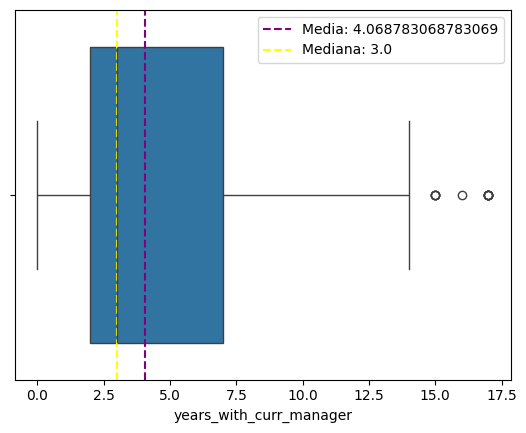

In [336]:
sns.boxplot(data=df_hr, x="years_with_curr_manager")

plt.axvline(media_anyos, color = 'purple', linestyle = "--", label = f"Media: {media_anyos}")
plt.axvline(mediana_anyos, color = 'yellow', linestyle = "--", label = f"Mediana: {mediana_anyos}")

plt.legend();

Como hay una distribución asimétrica de los datos con tendencia hacia la derecha, decidimos imputar con la mediana

In [337]:
# Simple Imputer para years_with_current_manager

objeto_imputacion_simple = SimpleImputer(strategy="median")

date_imputado = objeto_imputacion_simple.fit_transform(df_hr[['years_with_curr_manager']])

df_hr["years_with_curr_manager"] = date_imputado

df_hr["years_with_curr_manager"].isnull().sum()

C:\Users\al101\AppData\Local\Temp\ipykernel_12080\566708963.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hr["years_with_curr_manager"] = date_imputado


np.int64(0)

In [338]:
df_hr["years_with_curr_manager"].value_counts(dropna=False)

years_with_curr_manager
2.0     322
3.0     270
0.0     234
7.0     194
8.0      99
4.0      89
1.0      69
9.0      55
5.0      29
6.0      27
11.0     22
10.0     20
13.0     12
12.0     12
17.0      7
15.0      4
14.0      4
16.0      1
Name: count, dtype: int64

Como monthly_income tiene una media y una mediana tan diferentes, decidimos imputar con la mediana

In [339]:
media_ingreso = df_hr["monthly_income"].mean()
mediana_ingreso = df_hr["monthly_income"].median()

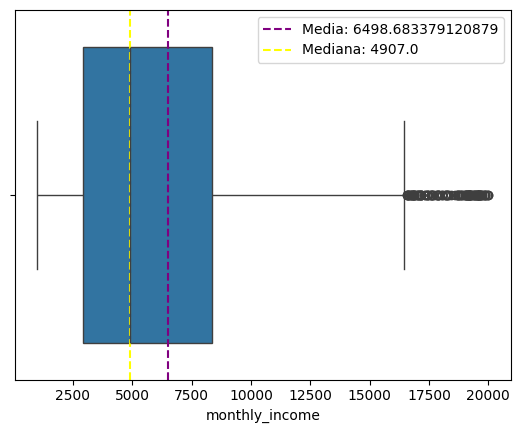

In [340]:
sns.boxplot(data=df_hr, x="monthly_income")

plt.axvline(media_ingreso, color = 'purple', linestyle = "--", label = f"Media: {media_ingreso}")
plt.axvline(mediana_ingreso, color = 'yellow', linestyle = "--", label = f"Mediana: {mediana_ingreso}")

plt.legend();

In [341]:
# Simple Imputer para montly_income 

objeto_imputacion_simple = SimpleImputer(strategy="median")

ingresos_imputados = objeto_imputacion_simple.fit_transform(df_hr[['monthly_income']])

df_hr["monthly_income"] = ingresos_imputados

df_hr["monthly_income"].isnull().sum()

C:\Users\al101\AppData\Local\Temp\ipykernel_12080\3153769578.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hr["monthly_income"] = ingresos_imputados


np.int64(0)

In [342]:
def imputar_media_sklearn(df, columnas):
    # df = df.copy()

    # crear objeto imputador
    imputador = SimpleImputer(strategy="mean")

    # aplicar imputación a varias columnas
    datos_imputados = imputador.fit_transform(df[columnas])

    # volver a asignar al dataframe
    df[columnas] = datos_imputados
    
    for columna in columnas:
        df[columna] = df[columna].round().astype("Int64")

    # comprobar nulos
    print("Nulos después de imputar:")
    print(df[columnas].isnull().sum())

    return df

In [ ]:
imputar_media_sklearn(df_hr, ["training_times_last_year", "age", "job_satisfaction"])

Imputación de nulos de las columnas categóricas

In [344]:
nulos_cat_hr = (df_hr.select_dtypes(include="object").isnull().sum()/df_hr.shape[0] * 100).sort_values(ascending=False)

nulos_cat_hr = nulos_cat_hr.reset_index()

nulos_cat_hr.rename(columns={"index": "nombre_columna", 0: "%_nulos"}, inplace = True)

mascara_nulos = nulos_cat_hr["%_nulos"] > 0

nulos_cat_hr = nulos_cat_hr[mascara_nulos]

nulos_cat_hr

,nombre_columna,%_nulos
0,marital_status,8.979592
1,business_travel,7.959184
2,education_field,3.945578
3,department,1.972789


In [345]:
df_hr["marital_status"].value_counts(dropna=False)

marital_status
Married     606
Single      436
Divorced    296
NaN         132
Name: count, dtype: int64

In [346]:
df_hr["business_travel"].value_counts(dropna=False)

business_travel
Travel_Rarely        951
Travel_Frequently    263
Non_Travel           139
NaN                  117
Name: count, dtype: int64

In [347]:
df_hr["education_field"].value_counts(dropna=False)

education_field
Life Sciences       581
Medical             447
Marketing           152
Technical Degree    130
Other                79
NaN                  58
Human Resources      23
Name: count, dtype: int64

In [348]:
df_hr["department"].value_counts(dropna=False)

department
Research & Development    939
Sales                     439
Human Resources            63
NaN                        29
Name: count, dtype: int64

Imputamos las columnas de marital_status y education_field creando una nueva categoría y las columnas de business_travel y department las imputamos por la moda 

In [349]:
columnas_moda = ["business_travel", "department"]
columnas_desconocido = ["marital_status", "education_field"]

In [350]:
def imputacion_cat_moda(df, columns):
    for col in columns:
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)
        print(f"El numero total de nulos en la columna {col} es {df[col].isnull().sum()}")

In [351]:
imputacion_cat_moda(df_hr, columnas_moda)

El numero total de nulos en la columna business_travel es 0
El numero total de nulos en la columna department es 0


C:\Users\al101\AppData\Local\Temp\ipykernel_12080\3944418770.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(moda)


In [352]:
df_hr["business_travel"].value_counts(dropna=False)

business_travel
Travel_Rarely        1068
Travel_Frequently     263
Non_Travel            139
Name: count, dtype: int64

In [353]:
def imputacion_cat_desconocido(df, columns):
    for col in columns:
        df[col] = df[col].fillna("Unknown")
        print(f"El numero total de nulos en la columna {col} es {df[col].isnull().sum()}")

In [354]:
imputacion_cat_desconocido(df_hr, columnas_desconocido)

El numero total de nulos en la columna marital_status es 0
El numero total de nulos en la columna education_field es 0


C:\Users\al101\AppData\Local\Temp\ipykernel_12080\3498378593.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna("Unknown")


In [355]:
df_hr["marital_status"].value_counts(dropna=False)

marital_status
Married     606
Single      436
Divorced    296
Unknown     132
Name: count, dtype: int64

In [356]:
df_hr["over_time"].value_counts(dropna=False)

over_time
False    1021
True      405
<NA>       44
Name: count, dtype: Int64

In [357]:
def imputacion_overtime_moda(df, column):
    moda = df[column].mode()[0]
    df[column] = df[column].fillna(moda)
    print(f"EL numero total de nulos en la columna {column} es {df[column].isnull().sum()}")

In [358]:
imputacion_overtime_moda(df_hr, "over_time")

EL numero total de nulos en la columna over_time es 0


C:\Users\al101\AppData\Local\Temp\ipykernel_12080\966421033.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].fillna(moda)


In [359]:
df_hr["attrition"].value_counts(dropna=False)

attrition
False    1233
True      237
Name: count, dtype: int64

## Decidir qué columnas no nos aportan información

In [360]:
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1470 non-null   Int64  
 1   attrition                   1470 non-null   bool   
 2   business_travel             1470 non-null   object 
 3   daily_rate                  1470 non-null   int64  
 4   department                  1470 non-null   object 
 5   distance_from_home          1470 non-null   int64  
 6   education                   1470 non-null   int64  
 7   education_field             1470 non-null   object 
 8   employee_count              1470 non-null   int64  
 9   employee_number             1470 non-null   object 
 10  environment_satisfaction    1470 non-null   int64  
 11  gender                      1470 non-null   object 
 12  hourly_rate                 1470 non-null   int64  
 13  job_involvement             1470 non-n

Decidimos borrar las columnas over18, employee_count y standard_hours.
No aportan información relevante, porque todos los registros tienen el mismo valor y son redundantes. 

In [361]:
def borrar_columnas(df, columns):
    df.drop(columns, inplace=True, errors="ignore", axis=1)

In [362]:
borrar_columnas(df_hr, ["over18", "employee_count", "standard_hours"])

C:\Users\al101\AppData\Local\Temp\ipykernel_12080\873132074.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns, inplace=True, errors="ignore", axis=1)


In [363]:
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1470 non-null   Int64  
 1   attrition                   1470 non-null   bool   
 2   business_travel             1470 non-null   object 
 3   daily_rate                  1470 non-null   int64  
 4   department                  1470 non-null   object 
 5   distance_from_home          1470 non-null   int64  
 6   education                   1470 non-null   int64  
 7   education_field             1470 non-null   object 
 8   employee_number             1470 non-null   object 
 9   environment_satisfaction    1470 non-null   int64  
 10  gender                      1470 non-null   object 
 11  hourly_rate                 1470 non-null   int64  
 12  job_involvement             1470 non-null   int64  
 13  job_level                   1470 non-n